# Notebook 8 -- Error Analysis, Explainability, and Reporting

**Goal:** turn model outputs into interpretable analysis.

A strong ML project does not stop after a metric table. It explains:

- which features influence the model,
- where the model is biased,
- which crops/zones are difficult,
- whether errors show spatial structure,
- what limitations remain.

In [1]:
# Core scientific stack
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Resolve project root whether the notebook is run from /notebooks or from the repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42


def print_section(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

# Notebook-aware figure saving -------------------------------------------------
# Every plot generated in this notebook is saved under reports/figures/.
# The counter prevents overwriting plots produced inside loops.
import re

NOTEBOOK_ID = "08_error_analysis_explainability_and_reporting"
_FIGURE_SAVE_COUNTER = 1


def _safe_filename(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_") or "figure"


def save_figure(fig, name: str = "figure", dpi: int = 180):
    """Save a matplotlib figure to reports/figures with a notebook-specific name."""
    global _FIGURE_SAVE_COUNTER
    filename = f"{NOTEBOOK_ID}_{_FIGURE_SAVE_COUNTER:02d}_{_safe_filename(name)}.png"
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path.relative_to(PROJECT_ROOT)}")
    _FIGURE_SAVE_COUNTER += 1
    return path


## 8.1 Loading the tuned model predictions and metadata

In [2]:
import joblib
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

PRED_PATH = TABLES_DIR / "tuned_model_predictions_notebook07.csv"
MODEL_PATH = MODELS_DIR / "best_tuned_model_notebook07.joblib"
METADATA_PATH = MODELS_DIR / "best_tuned_model_metadata_notebook07.json"

if PRED_PATH.exists():
    predictions = pd.read_csv(PRED_PATH)
else:
    raise FileNotFoundError("Run Notebook 7 first to create tuned predictions.")

if MODEL_PATH.exists():
    best_model = joblib.load(MODEL_PATH)
else:
    raise FileNotFoundError("Run Notebook 7 first to save the tuned model.")

metadata = json.loads(METADATA_PATH.read_text()) if METADATA_PATH.exists() else {}
TARGET = metadata.get("target", "yield_kg_ha")
best_model_name = metadata.get("best_model", predictions["model"].iloc[0])

best_preds = predictions.query("model == @best_model_name").copy()
print("Best model:", best_model_name)
print(best_preds.shape)
display(best_preds.head())

Best model: random_forest
(122, 10)


,state,zone,agroecological_zone,crop,season,yield_kg_ha,prediction,residual,abs_error,model
0,Benue,North Central,Southern Guinea Savannah,MAIZE,major,1124.413179,1586.840628,-462.427448,462.427448,random_forest
1,Nasarawa,North Central,Southern Guinea Savannah,MAIZE,major,1169.887511,1277.497456,-107.609945,107.609945,random_forest
2,Niger,North Central,Southern Guinea Savannah,MAIZE,major,1180.496021,1404.034373,-223.538351,223.538351,random_forest
3,Bauchi,North East,Sudan Savannah,MAIZE,major,1348.535400,1310.564703,37.970697,37.970697,random_forest
4,Yobe,North East,Sahel / Sudan Savannah,MAIZE,major,1149.806247,1258.786376,-108.980129,108.980129,random_forest


## 8.2 Global error profile

,residual
count,122.000000
mean,-192.815886
std,1426.423209
min,-3510.338597
1%,-2576.332885
5%,-1679.755452
25%,-674.640850
50%,-332.895403
75%,-60.898996
95%,1996.417446


Saved figure: reports\figures\08_error_analysis_explainability_and_reporting_01_figure_01.png


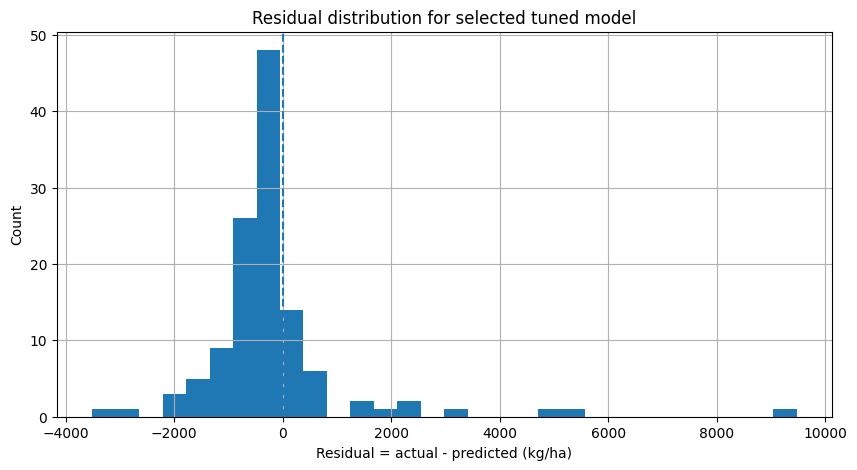

In [3]:
error_summary = best_preds["residual"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("residual")
display(error_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(best_preds["residual"], bins=30)
ax.axvline(0, linestyle="--")
ax.set_xlabel("Residual = actual - predicted (kg/ha)")
ax.set_ylabel("Count")
ax.set_title("Residual distribution for selected tuned model")
save_figure(fig, "figure_01")
plt.show()

fig.savefig(FIGURES_DIR / "residual_distribution_notebook08.png", dpi=180, bbox_inches="tight")

## 8.3 Error by crop, season, and agroecological zone

This section makes the model's failure modes explicit.

In [4]:
def grouped_error(df, group_cols):
    return (
        df.groupby(group_cols, as_index=False)
        .agg(
            n=(TARGET, "size"),
            mean_actual=(TARGET, "mean"),
            mean_prediction=("prediction", "mean"),
            bias=("residual", "mean"),
            mae=("residual", lambda x: x.abs().mean()),
            rmse=("residual", lambda x: np.sqrt(np.mean(np.square(x)))),
        )
        .sort_values("mae", ascending=False)
    )

crop_error = grouped_error(best_preds, ["crop"])
zone_error = grouped_error(best_preds, ["agroecological_zone"])
season_error = grouped_error(best_preds, ["season"])

print_section("Crop error")
display(crop_error.head(20))
print_section("Agroecological-zone error")
display(zone_error)
print_section("Season error")
display(season_error)

crop_error.to_csv(TABLES_DIR / "error_by_crop_notebook08.csv", index=False)
zone_error.to_csv(TABLES_DIR / "error_by_agroecological_zone_notebook08.csv", index=False)
season_error.to_csv(TABLES_DIR / "error_by_season_notebook08.csv", index=False)


Crop error


,crop,n,mean_actual,mean_prediction,bias,mae,rmse
0,BANANA,1,9969.026000,4628.576807,5340.449193,5340.449193,5340.449193
20,WHITEYAM,1,1530.552000,5040.890597,-3510.338597,3510.338597,3510.338597
19,TOMATO,6,3054.508267,2133.325424,921.182843,2460.178010,4018.681114
15,PLANTAIN,3,6570.121000,5088.564836,1481.556164,2038.569382,2264.829017
3,CASHEW,1,261.032800,2282.234024,-2021.201224,2021.201224,2021.201224
6,COCOA,1,435.217300,2049.115612,-1613.898312,1613.898312,1613.898312
21,YAM,7,4835.802274,5432.788342,-596.986069,1587.529600,1700.902000
13,OKRO,7,1503.869414,1860.417232,-356.547818,1057.242212,1322.553173
5,CHILLI PEPPER(SHOMBO),8,2909.200875,2639.636730,269.564145,1015.517412,1899.706540
4,CASSAVA,8,5581.161625,5698.449444,-117.287819,958.863191,1223.754249



Agroecological-zone error


,agroecological_zone,n,mean_actual,mean_prediction,bias,mae,rmse
0,Derived Savannah / Humid Forest Transition,26,3024.234104,3443.537731,-419.303627,1440.842323,1962.562192
1,Humid Forest,8,3516.257260,3979.897252,-463.639992,1293.100267,1684.161571
2,Mangrove / Coastal Rainforest,5,4538.644532,4041.881298,496.763233,1135.581711,1390.269752
4,Southern Guinea Savannah,47,1831.510638,2000.525514,-169.014876,685.823968,1509.697740
5,Sudan Savannah,28,1474.695031,1507.540223,-32.845192,371.838462,602.892484
3,Sahel / Sudan Savannah,8,929.578753,1246.200685,-316.621932,316.621932,341.831761



Season error


,season,n,mean_actual,mean_prediction,bias,mae,rmse
0,major,109,2243.112879,2411.765818,-168.652939,839.597375,1474.181783
1,minor,13,1520.242654,1915.655554,-395.412900,549.744312,1032.259488


## 8.4 Bias plot by agroecological zone

Positive residual means the model underpredicts actual yield. Negative residual means the model overpredicts yield.

Saved figure: reports\figures\08_error_analysis_explainability_and_reporting_02_figure_02.png


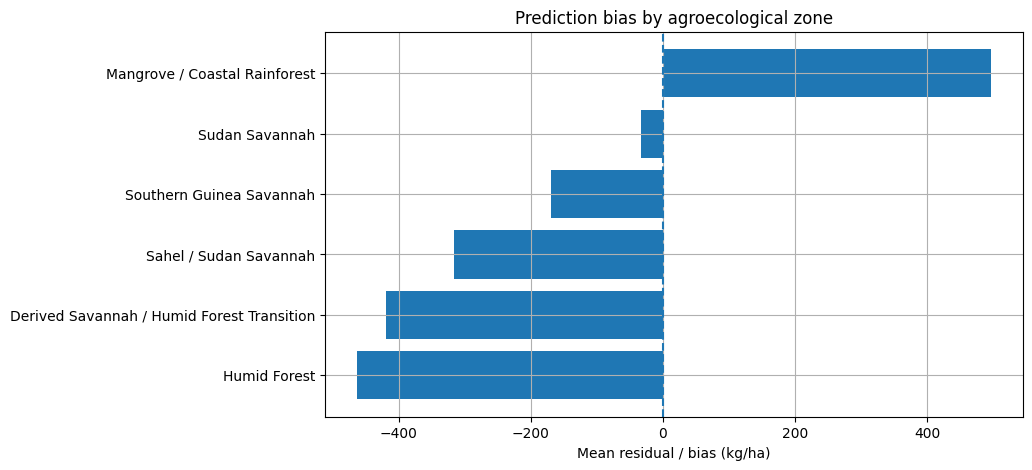

In [5]:
plot_df = zone_error.sort_values("bias")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["agroecological_zone"], plot_df["bias"])
ax.axvline(0, linestyle="--")
ax.set_xlabel("Mean residual / bias (kg/ha)")
ax.set_title("Prediction bias by agroecological zone")
save_figure(fig, "figure_02")
plt.show()

fig.savefig(FIGURES_DIR / "bias_by_agroecological_zone_notebook08.png", dpi=180, bbox_inches="tight")

## 8.5 Loading modeling data for feature importance

In [6]:
modeling_df = pd.read_csv(PROCESSED_DIR / "modeling_dataset.csv")
feature_cols = metadata.get("features")
if not feature_cols:
    raise ValueError("Feature list not found in model metadata. Re-run Notebook 7.")

# Use the same held-out states recorded by Notebook 7, if available.
test_states = metadata.get("test_states", [])
if test_states:
    eval_df = modeling_df[modeling_df["state"].isin(test_states)].copy()
else:
    eval_df = modeling_df.sample(frac=0.25, random_state=RANDOM_STATE).copy()

eval_df = eval_df[eval_df[TARGET].notna()].copy()
X_eval = eval_df[feature_cols]
y_eval = eval_df[TARGET]

print(X_eval.shape, y_eval.shape)
display(X_eval.head())

(122, 15) (122,)


,households_reporting_000,planted_area_ha,latitude,longitude,total_rainfall_mm,mean_tmean_c,mean_tmax_c,mean_tmin_c,mean_rh_percent,growing_degree_days,heat_stress_days,crop,season,zone,agroecological_zone
0,850.39,3.677952e+05,7.34,8.74,2791.10,25.855397,30.575918,21.825959,75.860397,11574.44,2.0,MAIZE,major,North Central,Southern Guinea Savannah
4,520.48,4.165471e+05,8.54,8.32,2904.55,26.104479,31.606562,21.643397,71.356986,11756.27,113.0,MAIZE,major,North Central,Southern Guinea Savannah
5,996.04,1.283121e+06,9.93,5.60,2890.03,25.298233,30.941260,20.284973,73.462041,11167.71,19.0,MAIZE,major,North Central,Southern Guinea Savannah
8,735.41,7.675438e+05,10.31,9.84,2890.11,25.006616,31.749658,19.222671,58.440726,10954.83,154.0,MAIZE,major,North East,Sudan Savannah
12,68.42,1.129229e+05,12.29,11.44,1475.44,27.200123,34.505973,20.767493,42.487863,12556.09,346.0,MAIZE,major,North East,Sahel / Sudan Savannah


## 8.6 Permutation importance

Permutation importance measures how much the model performance declines when each feature is shuffled. It is model-agnostic and works with the full preprocessing pipeline.

,feature,importance_mean,importance_std
11,crop,930.704348,67.020138
8,mean_rh_percent,120.548837,49.897611
0,households_reporting_000,25.540842,31.069576
1,planted_area_ha,24.511909,20.271771
7,mean_tmin_c,12.332139,7.832714
2,latitude,7.916563,9.947446
6,mean_tmax_c,7.688033,10.121471
3,longitude,5.898063,3.480988
13,zone,5.436290,3.264943
5,mean_tmean_c,2.320250,5.210715


Saved figure: reports\figures\08_error_analysis_explainability_and_reporting_03_figure_03.png


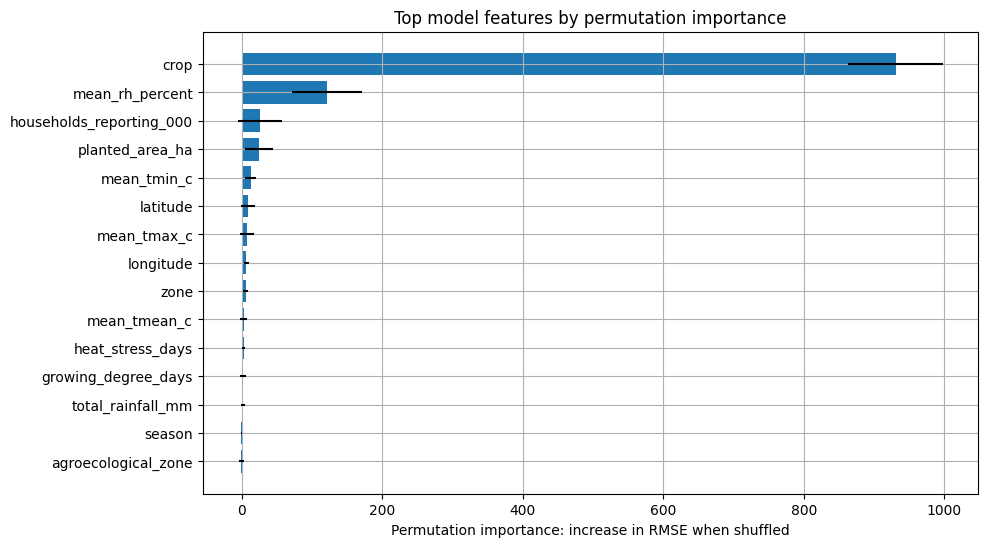

In [7]:
perm = permutation_importance(
    best_model,
    X_eval,
    y_eval,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(perm_df)
perm_df.to_csv(TABLES_DIR / "permutation_importance_notebook08.csv", index=False)

plot_df = perm_df.head(20).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
ax.set_xlabel("Permutation importance: increase in RMSE when shuffled")
ax.set_title("Top model features by permutation importance")
save_figure(fig, "figure_03")
plt.show()

fig.savefig(FIGURES_DIR / "permutation_importance_notebook08.png", dpi=180, bbox_inches="tight")

## 8.7 Tree-model encoded feature importance, when available

Permutation importance is preferred for the final interpretation. Native impurity importance can still be useful for debugging tree models.

In [8]:
try:
    fitted_preprocessor = best_model.named_steps["preprocess"]
    fitted_model = best_model.named_steps["model"]
    encoded_features = fitted_preprocessor.get_feature_names_out()
    if hasattr(fitted_model, "feature_importances_"):
        native_df = pd.DataFrame({
            "encoded_feature": encoded_features,
            "importance": fitted_model.feature_importances_,
        }).sort_values("importance", ascending=False)
        display(native_df.head(30))
        native_df.to_csv(TABLES_DIR / "native_feature_importance_notebook08.csv", index=False)
    else:
        print("Selected model does not expose native feature_importances_.")
except Exception as exc:
    print("Could not compute native feature importance:", repr(exc))

,encoded_feature,importance
15,crop_CASSAVA,0.151487
32,crop_YAM,0.121789
8,mean_rh_percent,0.113403
6,mean_tmax_c,0.092377
0,households_reporting_000,0.086744
1,planted_area_ha,0.078062
31,crop_WHITEYAM,0.050973
26,crop_PLANTAIN,0.046065
2,latitude,0.039621
23,crop_OIL PALM,0.031809


## 8.8 Partial dependence for important numeric features

Partial dependence is useful for communicating how the model responds to rainfall, temperature, area, and remote-sensing indices. This cell only plots features that are numeric and present.

Saved figure: reports\figures\08_error_analysis_explainability_and_reporting_04_figure_04.png


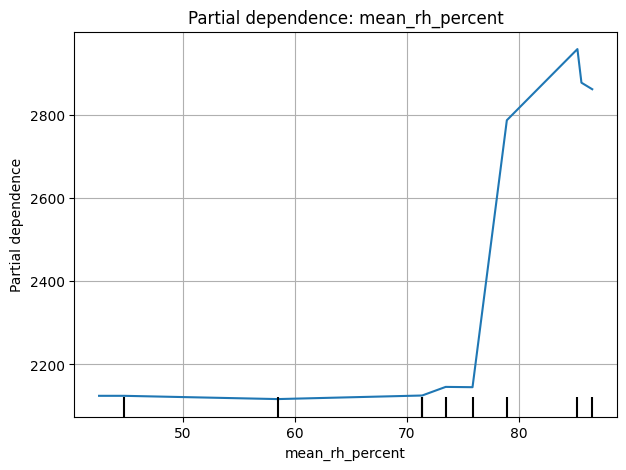

Saved figure: reports\figures\08_error_analysis_explainability_and_reporting_05_figure_04.png


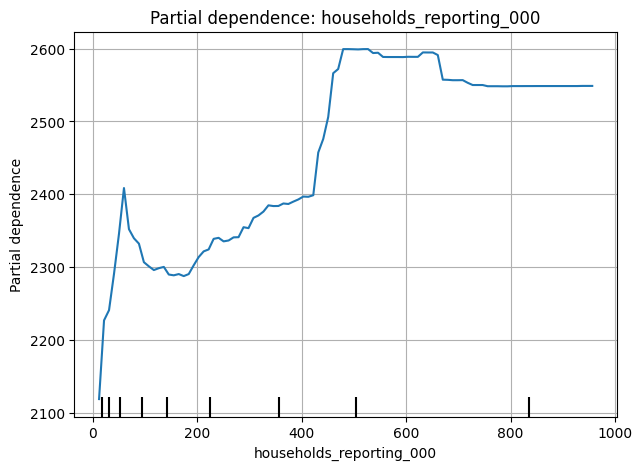

Saved figure: reports\figures\08_error_analysis_explainability_and_reporting_06_figure_04.png


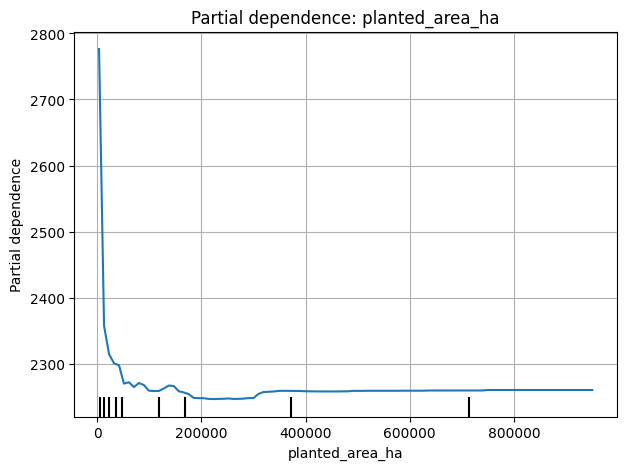

In [9]:
metadata_numeric = metadata.get("numeric_features", [])
important_numeric = [f for f in perm_df["feature"].head(10).tolist() if f in metadata_numeric and f in X_eval.columns]
important_numeric = important_numeric[:3]

if important_numeric:
    for feature in important_numeric:
        fig, ax = plt.subplots(figsize=(7, 5))
        PartialDependenceDisplay.from_estimator(best_model, X_eval, [feature], ax=ax)
        ax.set_title(f"Partial dependence: {feature}")
        save_figure(fig, "figure_04")
        plt.show()
        fig.savefig(FIGURES_DIR / f"partial_dependence_{feature}_notebook08.png", dpi=180, bbox_inches="tight")
else:
    print("No numeric features available among the top permutation-importance variables.")

## 8.9 Spatial residual diagnostic

This plot checks whether errors cluster geographically. It uses state centroids rather than a full shapefile, which keeps the repository lightweight.

,state,mean_residual,mae,n,geopolitical_zone,agroecological_zone,latitude,longitude
8,Osun,-155.439612,1926.106686,15,South West,Derived Savannah / Humid Forest Transition,7.56,4.52
3,Imo,-463.639992,1293.100267,8,South East,Humid Forest,5.49,7.03
5,Lagos,496.763233,1135.581711,5,South West,Mangrove / Coastal Rainforest,6.52,3.38
6,Nasarawa,353.548679,1090.764092,15,North Central,Southern Guinea Savannah,8.54,8.32
2,Enugu,-779.118192,779.118192,11,South East,Derived Savannah / Humid Forest Transition,6.45,7.50
1,Benue,-382.161726,546.245210,16,North Central,Southern Guinea Savannah,7.34,8.74
7,Niger,-445.771358,445.771358,16,North Central,Southern Guinea Savannah,9.93,5.60
0,Bauchi,88.088261,412.522166,17,North East,Sudan Savannah,10.31,9.84
9,Yobe,-316.621932,316.621932,8,North East,Sahel / Sudan Savannah,12.29,11.44
4,Jigawa,-219.742346,308.963647,11,North West,Sudan Savannah,12.23,9.56


Saved figure: reports\figures\08_error_analysis_explainability_and_reporting_07_figure_05.png


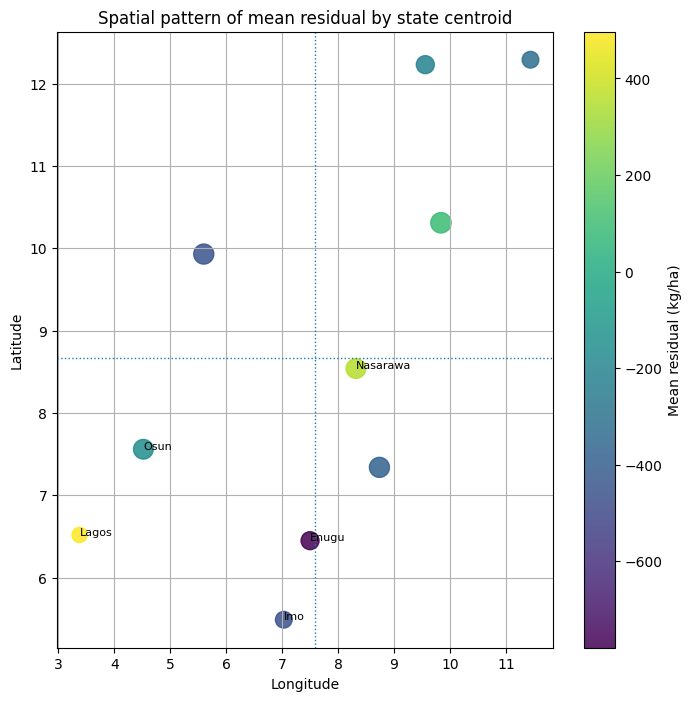

In [10]:
state_meta = pd.read_csv(PROCESSED_DIR / "state_metadata.csv")
state_errors = (
    best_preds.groupby("state", as_index=False)
    .agg(mean_residual=("residual", "mean"), mae=("abs_error", "mean"), n=("residual", "size"))
    .merge(state_meta, on="state", how="left")
)

display(state_errors.sort_values("mae", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(state_errors["longitude"], state_errors["latitude"], c=state_errors["mean_residual"], s=80 + 8 * state_errors["n"], alpha=0.85)
for _, row in state_errors.nlargest(5, "mae").iterrows():
    ax.annotate(row["state"], (row["longitude"], row["latitude"]), fontsize=8)
ax.axhline(state_errors["latitude"].mean(), linestyle=":", linewidth=1)
ax.axvline(state_errors["longitude"].mean(), linestyle=":", linewidth=1)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Spatial pattern of mean residual by state centroid")
plt.colorbar(sc, ax=ax, label="Mean residual (kg/ha)")
save_figure(fig, "figure_05")
plt.show()

fig.savefig(FIGURES_DIR / "spatial_residual_centroids_notebook08.png", dpi=180, bbox_inches="tight")